# Crypto market data: returns, trend baseline and correlations
**Problem:** Characterise the major crypto pairs: risk/return, a naive trend baseline, and how the coins co-move.
**Approach:** Fetch the full daily candle history for 12 USDT pairs from the Poloniex v2 public API, compute summary statistics for BTC, fit a linear-regression baseline (last 100 days held out), then build and export a cross-coin correlation matrix.
**Data:** Public Poloniex market data (no account or API key needed).
**Metrics module:** `summary_stats` comes from the local `data-science/scripts/risk_metrics.py` module.
**Note:** ported from the retired legacy endpoint (`returnChartData`) to the v2 `/markets/{symbol}/candles` API. The correlation matrix is aligned on dates.

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt

import pandas as pd
import requests
import sys
sys.path.append('../../scripts')  # local risk_metrics module (data-science/scripts/)
import risk_metrics as rm

import datetime as dt
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
API = "https://api.poloniex.com"  # Poloniex v2 public market-data API (no key needed)
CANDLE_COLUMNS = ["low", "high", "open", "close", "amount", "quantity", "buyTakerAmount",
                  "buyTakerQuantity", "tradeCount", "ts", "weightedAverage", "interval",
                  "startTime", "closeTime"]


def return_chart_data(pair: str, interval: str = "DAY_1") -> pd.DataFrame:
    """Full candle history for a legacy-style pair name such as 'USDT_BTC'.

    Replaces the retired ``Poloniex().returnChartData``. It pages backwards 500
    candles at a time and returns the same core columns, with ``date`` in unix
    seconds like the legacy API.
    """
    quote, base = pair.split("_")                  # legacy QUOTE_BASE -> v2 BASE_QUOTE
    symbol = f"{base}_{quote}"
    rows, end = [], None
    while True:
        params = {"interval": interval, "limit": 500}
        if end is not None:
            params["endTime"] = end
        resp = requests.get(f"{API}/markets/{symbol}/candles", params=params, timeout=30)
        if resp.status_code != 200:
            print(f"{pair}: HTTP {resp.status_code} {resp.text[:80]}; skipped")
            break
        batch = resp.json()
        rows = batch + rows
        if len(batch) < 500:
            break
        end = int(batch[0][12]) - 1                # oldest startTime - 1 ms
    frame = pd.DataFrame(rows, columns=CANDLE_COLUMNS)
    num = ["low", "high", "open", "close", "amount", "quantity", "weightedAverage"]
    frame[num] = frame[num].astype(float)
    frame["date"] = frame["startTime"].astype("int64") // 1000
    return (frame[["date", "high", "low", "open", "close", "amount", "quantity", "weightedAverage"]]
            .drop_duplicates("date").reset_index(drop=True))

## Fetch daily candles for 12 USDT pairs

In [3]:
ticker = 'USDT_BTC'
ticker1 = 'USDT_BTT'
ticker2 = 'USDT_ETH'
ticker3 = 'USDT_LTC'
ticker4 = 'USDT_DOGE'
ticker5 = 'USDT_XRP'
ticker6 = 'USDT_ZEC'
ticker7 = 'USDT_BCH'
ticker8 = 'USDT_TRX'
ticker9 = 'USDT_UNI'
ticker10 = 'USDT_LINK'
ticker11 = 'USDT_ATOM'

In [4]:
frame = return_chart_data(ticker)
frame1 = return_chart_data(ticker1)
frame2 = return_chart_data(ticker2)
frame3 = return_chart_data(ticker3)
frame4 = return_chart_data(ticker4)
frame5 = return_chart_data(ticker5)
frame6 = return_chart_data(ticker6)
frame7 = return_chart_data(ticker7)
frame8 = return_chart_data(ticker8)
frame9 = return_chart_data(ticker9)
frame10 = return_chart_data(ticker10)
frame11 = return_chart_data(ticker11)
print(f"BTC history: {len(frame)} daily candles")

BTC history: 4241 daily candles


In [5]:
frame.describe()

,date,high,low,open,close,amount,quantity,weightedAverage
count,4.241000e+03,4241.000000,4241.000000,4241.000000,4241.000000,4.241000e+03,4241.000000,4241.000000
mean,1.607472e+09,31360.858326,30080.227946,30741.459795,30761.753101,6.616831e+07,2187.323396,30735.394683
std,1.057895e+08,33310.647627,32213.565974,32778.733249,32786.099201,1.109898e+08,3640.105519,32780.309873
min,1.424304e+09,219.010000,99.000000,191.290000,178.710000,0.000000e+00,0.000000,207.450000
25%,1.515888e+09,4368.580000,4050.000000,4206.800000,4202.000000,3.057339e+06,317.376757,4176.040000
50%,1.607472e+09,17099.920000,16501.620000,16775.050000,16782.930000,1.650311e+07,1035.900238,16781.850000
75%,1.699056e+09,55451.420000,51682.930000,53951.990000,53964.440000,7.491374e+07,2724.388662,54177.380000
max,1.790640e+09,125968.780000,123075.410000,124562.520000,124618.020000,1.208160e+09,48896.616807,124797.270000


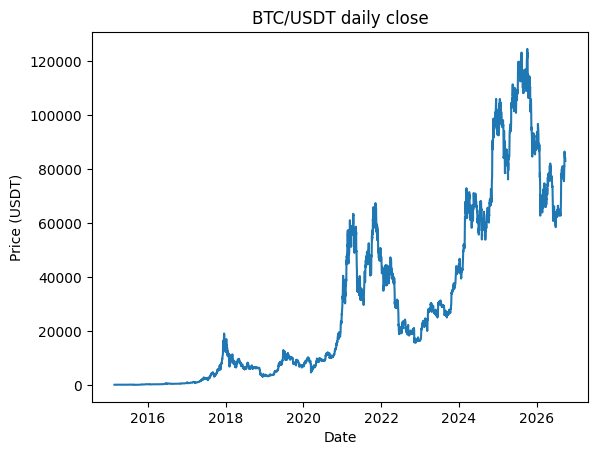

In [6]:
plt.plot(pd.to_datetime(frame['date'], unit='s'), frame['close'])
plt.title('BTC/USDT daily close')
plt.xlabel('Date')
plt.ylabel('Price (USDT)');

## Risk/return summary (BTC)

In [7]:
r = frame[['close']].pct_change()  # daily returns of the close price

In [8]:
rm.summary_stats(r, riskfree_rate=0.03, periods_per_year=253)

,Annualized Return,Annualized Volatility,Sharpe Ratio,Max Drawdown
close,0.416174,0.563735,0.66512,-0.832693


## Linear-regression baseline (last 100 days held out)

In [9]:
# day number (row index) as the single regression feature
x0 = frame.index
y0 = frame['close']

In [10]:
x = np.array([x0]).reshape(-1, 1)
y = np.array([y0]).reshape(-1, 1)

In [11]:
xTrain = x[:(len(x)-100)]
xTest = x[(len(x)-100):]

yTrain = y[:(len(x)-100)]
yTest = y[(len(x)-100):]

In [12]:
linearRegressor = LinearRegression()

In [13]:
linearRegressor.fit(xTrain, yTrain)

LinearRegression()

In [14]:
yPrediction = linearRegressor.predict(xTest)

In [15]:
mean_squared_error(yTest, yPrediction)

138534048.6622265

In [16]:
r2_score(yTest, yPrediction)

-1.008861040029693

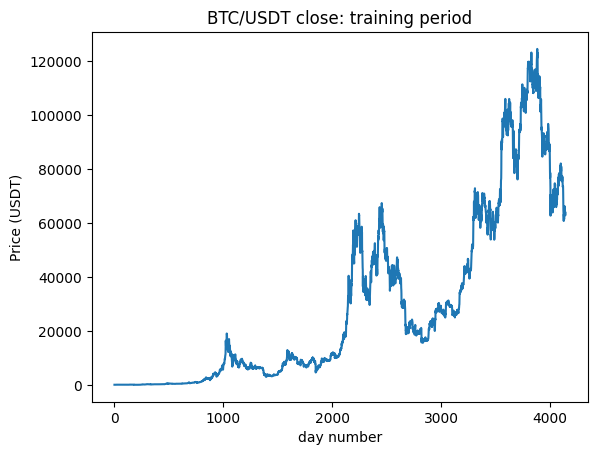

In [17]:
plt.plot(xTrain, yTrain)
plt.title('BTC/USDT close: training period')
plt.xlabel('day number')
plt.ylabel('Price (USDT)');

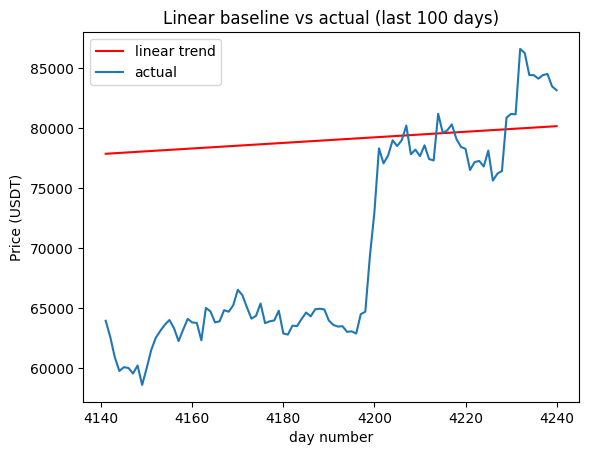

In [18]:
plt.plot(xTest, yPrediction, 'r-', label='linear trend')
plt.plot(xTest, yTest, label='actual')
plt.title('Linear baseline vs actual (last 100 days)')
plt.xlabel('day number')
plt.ylabel('Price (USDT)')
plt.legend();

## Cross-coin correlation matrix

In [19]:
frames = [frame, frame1, frame2, frame3, frame4, frame5, frame6, frame7, frame8, frame9, frame10, frame11]
matrix = pd.concat([f.set_index("date")["close"] for f in frames], axis=1)  # aligned on date

In [20]:
matrix.columns = [ticker, ticker1, ticker2, ticker3, ticker4, ticker5, ticker6, ticker7, ticker8, ticker9, ticker10, ticker11]

In [21]:
matrixCompare = matrix.corr()

In [22]:
df = pd.DataFrame(matrixCompare)

In [23]:
df.to_csv(f'BTC_correlation_matrix_periodMax_{dt.date.today():%d%b%Y}.csv')

In [24]:
matrixCompare

,USDT_BTC,USDT_BTT,USDT_ETH,USDT_LTC,USDT_DOGE,USDT_XRP,USDT_ZEC,USDT_BCH,USDT_TRX,USDT_UNI,USDT_LINK,USDT_ATOM
USDT_BTC,1.000000,-0.051804,0.869887,0.411249,0.712284,0.881906,0.130316,-0.057019,0.881200,0.056022,0.381554,-0.064747
USDT_BTT,-0.051804,1.000000,0.227875,0.808214,0.420788,-0.001727,0.074968,0.604545,-0.187067,0.871308,0.720784,0.607700
USDT_ETH,0.869887,0.227875,1.000000,0.547229,0.815713,0.704984,0.059945,-0.046640,0.539732,0.412193,0.591663,0.413418
USDT_LTC,0.411249,0.808214,0.547229,1.000000,0.623093,0.479301,0.139024,0.605848,-0.042476,0.908219,0.876049,0.675106
USDT_DOGE,0.712284,0.420788,0.815713,0.623093,1.000000,0.679398,0.097016,0.474391,0.431696,0.584377,0.678331,0.360047
USDT_XRP,0.881906,-0.001727,0.704984,0.479301,0.679398,1.000000,0.205672,0.204992,0.828081,0.066171,0.364712,-0.100049
USDT_ZEC,0.130316,0.074968,0.059945,0.139024,0.097016,0.205672,1.000000,0.394927,0.526795,-0.002034,0.040531,-0.085802
USDT_BCH,-0.057019,0.604545,-0.046640,0.605848,0.474391,0.204992,0.394927,1.000000,0.236924,0.675745,0.787056,0.180484
USDT_TRX,0.881200,-0.187067,0.539732,-0.042476,0.431696,0.828081,0.526795,0.236924,1.000000,-0.208115,0.086449,-0.353731
USDT_UNI,0.056022,0.871308,0.412193,0.908219,0.584377,0.066171,-0.002034,0.675745,-0.208115,1.000000,0.876935,0.653312


## Available currencies and tickers

In [25]:
currency0 = requests.get(f"{API}/currencies", timeout=30).json()
currency1 = requests.get(f"{API}/markets/ticker24h", timeout=30).json()

In [26]:
currencies = pd.DataFrame([{"currency": k, **v} for item in currency0 for k, v in item.items()])
tickers24h = pd.DataFrame(currency1)

In [27]:
currencies[["currency", "name", "blockchain", "delisted"]].head(), tickers24h[["symbol", "close", "dailyChange", "amount"]].head()

(  currency                  name blockchain  delisted
 0      0XY              Oxytocin        SOL     False
 1        1  Ucan fix life in1day        BSC     False
 2   114514                114514        SOL     False
 3       21         2131KOBUSHIDE        SOL     False
 4        4                     4        BSC     False,
      symbol        close dailyChange       amount
 0  DASH_BTC     0.000727     -0.0546   0.00095529
 1  DOGE_BTC  0.000001127      0.0135  0.005420399
 2   LTC_BTC     0.000812     -0.0193   0.04304625
 3   XLM_BTC   0.00000274      0.0111  0.004972749
 4   XMR_BTC     0.006542      0.0151   0.58410911)